In [2]:
import pandas as pd
import numpy as np
import math
import statsmodels.api as sm
from scipy.optimize import minimize
from statsmodels.tools.numdiff import approx_hess
import matplotlib.pyplot as plt

In [3]:
tbill_df = pd.read_parquet("../_data/CRSP_30_day_T_bill_44_to_07.parquet")
ret_df = pd.read_parquet("../_data/CRSP_monthly_stock_44_to_07.parquet")
construction_start="1944-01"

In [4]:
tbill_df

,date,t30ret
0,1944-01-31,0.000293
1,1944-02-29,0.000289
2,1944-03-31,0.000238
3,1944-04-29,0.000277
4,1944-05-31,0.000261
...,...,...
763,2007-08-31,0.004205
764,2007-09-28,0.003347
765,2007-10-31,0.003212
766,2007-11-30,0.003395


In [5]:
ret_df

,date,vwretd,vwretx
0,1944-01-31,0.018030,0.016629
1,1944-02-29,0.003459,-0.001591
2,1944-03-31,0.024768,0.019977
3,1944-04-29,-0.016484,-0.017836
4,1944-05-31,0.050909,0.044927
...,...,...,...
763,2007-08-31,0.011593,0.009641
764,2007-09-28,0.040822,0.039307
765,2007-10-31,0.025911,0.024770
766,2007-11-30,-0.049362,-0.051309


In [6]:
def future_prod_excl_current(x):
    
    # [g1, g2, g3] -> [g2*g3, g3, 1]
    return x.iloc[::-1].cumprod().iloc[::-1].shift(-1, fill_value=1.0)

def monthly_annual(ret_df, tbill_df, end_year=2007):
    
    ret = ret_df.copy()
    rf = tbill_df.copy()

    ret["date"] = pd.to_datetime(ret["date"])
    rf["date"] = pd.to_datetime(rf["date"])

    # Match by month
    ret["ym"] = ret["date"].dt.to_period("M")
    rf["ym"] = rf["date"].dt.to_period("M")

    monthly = (
        ret[["ym", "vwretd", "vwretx"]]
        .merge(rf[["ym", "t30ret"]], on="ym", how="inner")
        .sort_values("ym")
        .reset_index(drop=True)
    )

    start_period = pd.Period(construction_start, "M")
    end_period = pd.Period(f"{end_year}-12", "M")

    monthly = monthly[
        (monthly["ym"] >= start_period) &
        (monthly["ym"] <= end_period)
    ].copy()

    monthly["year"] = monthly["ym"].dt.year

    # Monthly gross returns
    monthly["gross_mkt"] = 1.0 + monthly["vwretd"]
    monthly["gross_x"] = 1.0 + monthly["vwretx"]
    monthly["gross_rf"] = 1.0 + monthly["t30ret"]

    if (monthly[["gross_mkt", "gross_x", "gross_rf"]] <= 0).any().any():
        raise ValueError("Found gross return <= 0.")

    # Ex-dividend price index
    monthly["P_end"] = monthly["gross_x"].cumprod()
    monthly["P_beg"] = monthly["P_end"].shift(fill_value=1.0)

    # Monthly dividend
    monthly["div_month"] = monthly["P_beg"] * (monthly["vwretd"] - monthly["vwretx"])

    # Carry each month's dividend to year-end
    monthly["to_ye_rf"] = monthly.groupby("year")["gross_rf"].transform(future_prod_excl_current)
    monthly["to_ye_mkt"] = monthly.groupby("year")["gross_mkt"].transform(future_prod_excl_current)

    monthly["div_cash_piece"] = monthly["div_month"] * monthly["to_ye_rf"]
    monthly["div_market_piece"] = monthly["div_month"] * monthly["to_ye_mkt"]

    annual_div = (
        monthly.groupby("year", as_index=False)[["div_cash_piece", "div_market_piece"]]
        .sum()
        .rename(columns={
            "div_cash_piece": "D_cash",
            "div_market_piece": "D_market"
        })
    )

    annual_price = (
        monthly.groupby("year", as_index=False)["P_end"]
        .last()
        .rename(columns={"P_end": "P"})
    )

    annual = (
        annual_price
        .merge(annual_div, on="year", how="inner")
        .sort_values("year")
        .reset_index(drop=True)
    )

    # Annual log dividend growth
    annual["delta_d"] = np.log(annual["D_cash"] / annual["D_cash"].shift(1))
    annual["delta_d_M"] = np.log(annual["D_market"] / annual["D_market"].shift(1))

    # Annual total log returns
    annual["r"] = np.log((annual["P"] + annual["D_cash"]) / annual["P"].shift(1))
    annual["r_M"] = np.log((annual["P"] + annual["D_market"]) / annual["P"].shift(1))

    # Annual log price-dividend ratios
    annual["pd"] = np.log(annual["P"] / annual["D_cash"])
    annual["pd_M"] = np.log(annual["P"] / annual["D_market"])

    return monthly, annual

In [7]:
def replicate_table1(annual, start_year=1946, end_year=2007):
    
    growth = annual[
        (annual["year"] >= start_year) &
        (annual["year"] <= end_year)
    ].dropna(subset=["delta_d", "delta_d_M"]).copy()

    table1 = pd.DataFrame({
        "delta_d_M": growth["delta_d_M"].agg(["mean", "median", "std", "max", "min"]),
        "delta_d": growth["delta_d"].agg(["mean", "median", "std", "max", "min"]),
    })

    table1.index = ["Mean", "Median", "Standard deviation", "Maximum", "Minimum"]

    return growth, table1

In [8]:
def replicate_figure1(annual, start_year=1946, end_year=2007):
    
    growth = annual[
        (annual["year"] >= start_year) &
        (annual["year"] <= end_year)
    ].dropna(subset=["delta_d", "delta_d_M"]).copy()

    plt.figure(figsize=(8, 6))

    # Risk-free reinvestment
    plt.plot(
        growth["year"],
        growth["delta_d"],
        linewidth=1,
        label="Dividend Growth Rate, Reinvested in the Risk-free Rate"
    )

    # Market reinvestment
    plt.plot(
        growth["year"],
        growth["delta_d_M"],
        linestyle=":",
        linewidth=1,
        label="Dividend Growth Rate, Reinvested in the Aggregate Market"
    )

    plt.xlim(start_year, end_year)
    plt.xticks(list(range(int(math.ceil(start_year/10)*10), int(math.ceil(end_year/10)*10), 10)))
    plt.xlabel("Year")
    plt.ylabel(r"$\Delta d_t$")

    plt.legend(
        frameon=False,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.1),
        fontsize=10
    )

    plt.tight_layout()
    plt.savefig(f"figure1_{end_year}")
    plt.show()


In [9]:
def run_ols(annual, y_col, pd_col, start_year=1946, end_year=2007):
    
    reg = annual[["year", y_col, pd_col]].copy()
    reg["pd_lag"] = reg[pd_col].shift(1)

    reg = reg[
        (reg["year"] >= start_year) &
        (reg["year"] <= end_year)
    ].dropna(subset=[y_col, "pd_lag"]).copy()

    X = sm.add_constant(reg["pd_lag"])
    model = sm.OLS(reg[y_col], X).fit()

    return {
        "model": model,
        "reg_df": reg,
        "n": int(model.nobs),
        "const": model.params["const"],
        "const_se": model.bse["const"],
        "beta": model.params["pd_lag"],
        "beta_se": model.bse["pd_lag"],
        "r2": model.rsquared,
        "adj_r2": model.rsquared_adj,
    }

def replicate_table3(annual, start_year=1946, end_year=2007):
    
    res_rM = run_ols(annual, "r_M", "pd_M", start_year, end_year)
    res_r = run_ols(annual, "r", "pd", start_year, end_year)
    res_dM = run_ols(annual, "delta_d_M", "pd_M", start_year, end_year)
    res_d = run_ols(annual, "delta_d", "pd", start_year, end_year)

    table3 = pd.DataFrame({
        "r_M": [
            res_rM["const"], res_rM["const_se"],
            res_rM["beta"], res_rM["beta_se"],
            res_rM["r2"], res_rM["adj_r2"],
        ],
        "r": [
            res_r["const"], res_r["const_se"],
            res_r["beta"], res_r["beta_se"],
            res_r["r2"], res_r["adj_r2"],
        ],
        "delta_d_M": [
            res_dM["const"], res_dM["const_se"],
            res_dM["beta"], res_dM["beta_se"],
            res_dM["r2"], res_dM["adj_r2"],
        ],
        "delta_d": [
            res_d["const"], res_d["const_se"],
            res_d["beta"], res_d["beta_se"],
            res_d["r2"], res_d["adj_r2"],
        ],
    }, index=[
        "Constant",
        "SE(Constant)",
        "Lagged log PD coefficient",
        "SE(Lagged log PD)",
        "R2",
        "Adj. R2",
    ])

    models = {
        "r_M": res_rM["model"],
        "r": res_r["model"],
        "delta_d_M": res_dM["model"],
        "delta_d": res_d["model"],
        "sample_years": (
            int(res_r["reg_df"]["year"].min()),
            int(res_r["reg_df"]["year"].max())
        )
    }

    return table3, models

In [10]:
def fit_armax11_conditional(y, y_lag, x):

    """
    Fit the direct recursion

        y_t = c + phi*y_{t-1} + beta*x_t + e_t + theta*e_{t-1}

    by conditional Gaussian MLE with e_0 = 0.

    Returns phi, theta, beta, and the reported constant
    gamma0 = (c + beta * mean(x)) / (1 - phi).
    """

    y = np.asarray(y, dtype=float)
    y_lag = np.asarray(y_lag, dtype=float)
    x = np.asarray(x, dtype=float)

    T = len(y)

    # OLS starting values
    X0 = np.column_stack([np.ones(T), y_lag, x])
    b0 = np.linalg.lstsq(X0, y, rcond=None)[0]
    c0, phi0, beta0 = b0[0], b0[1], b0[2]

    starts = [
        np.array([c0, np.clip(phi0, -0.75, 0.75), -0.5, beta0]),
        np.array([c0, np.clip(phi0, -0.75, 0.75),  0.5, beta0]),
        np.array([c0,  0.5, -0.5, beta0]),
        np.array([c0,  0.5, -0.5, beta0]),
        np.array([c0, -0.5,  0.5, beta0]),
        np.array([c0,  0.5, -0.5, beta0]),
    ]

    bounds = [
        (None, None),      # c
        (-0.999, 0.999),   # phi
        (-0.999, 0.999),   # theta
        (None, None),      # beta
    ]

    def residual(params):
        c, phi, theta, beta = params
        e = np.zeros(T)
        for t in range(T):
            e_prev = e[t - 1] if t > 0 else 0.0
            e[t] = y[t] - c - phi * y_lag[t] - beta * x[t] - theta * e_prev
        return e

    def negloglike(params):
        c, phi, theta, beta = params

        if abs(phi) >= 0.999 or abs(theta) >= 0.999:
            return 1e12

        e = residual(params)
        s2 = np.mean(e ** 2)

        if (not np.isfinite(s2)) or s2 <= 0:
            return 1e12

        return 0.5 * T * (np.log(2 * np.pi) + 1.0 + np.log(s2))

    best = None
    for s in starts:
        res = minimize(negloglike, s, method="L-BFGS-B", bounds=bounds)
        if best is None or res.fun < best.fun:
            best = res

    if best is None:
        raise RuntimeError("ARMAX optimization failed.")

    c_hat, phi_hat, theta_hat, beta_hat = best.x

    # Numerical Hessian for covariance
    H = approx_hess(best.x, negloglike)
    try:
        cov = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(H)

    se = np.sqrt(np.maximum(np.diag(cov), 0.0))
    c_se, phi_se, theta_se, beta_se = se

    # Recursive fitted values
    fitted = np.zeros(T)
    ehat = np.zeros(T)
    for t in range(T):
        e_prev = ehat[t - 1] if t > 0 else 0.0
        fitted[t] = c_hat + phi_hat * y_lag[t] + beta_hat * x[t] + theta_hat * e_prev
        ehat[t] = y[t] - fitted[t]

    sse = float(np.sum((y - fitted) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - sse / sst

    k = 3
    adj_r2 = 1.0 - (1.0 - r2) * (T - 1) / (T - k - 1)

    xbar = float(np.mean(x))
    gamma0_hat = (c_hat + beta_hat * xbar) / (1.0 - phi_hat)

    # Delta-method SE for gamma0
    grad = np.array([
        1.0 / (1.0 - phi_hat),
        (c_hat + beta_hat * xbar) / (1.0 - phi_hat) ** 2,
        0.0,
        xbar / (1.0 - phi_hat),
    ])
    gamma0_var = float(grad @ cov @ grad)
    gamma0_se = np.sqrt(max(gamma0_var, 0.0))

    return {
        "success": bool(best.success),
        "message": best.message,
        "c": c_hat,
        "c_se": c_se,
        "phi": phi_hat,
        "phi_se": phi_se,
        "theta": theta_hat,
        "theta_se": theta_se,
        "beta": beta_hat,
        "beta_se": beta_se,
        "gamma0": gamma0_hat,
        "gamma0_se": gamma0_se,
        "r2": r2,
        "adj_r2": adj_r2,
        "fitted": fitted,
        "resid": y - fitted,
    }

def replicate_table4(annual, start_year=1946, end_year=2007):
    """
    Table 4 using:
      col 1: OLS AR(1)
      col 2: OLS on lagged return
      col 3: direct ARMAX(1,1) fit via scipy + approx_hess
    """
    reg = annual[["year", "delta_d_M", "r"]].copy()
    reg["dM_lag"] = reg["delta_d_M"].shift(1)
    reg["r_lag"] = reg["r"].shift(1)

    reg = reg[
        (reg["year"] >= start_year) &
        (reg["year"] <= end_year)
    ].dropna(subset=["delta_d_M", "dM_lag", "r_lag"]).reset_index(drop=True)

    # Column 1: OLS AR(1)
    X1 = sm.add_constant(reg["dM_lag"])
    m1 = sm.OLS(reg["delta_d_M"], X1).fit()

    # Column 2: OLS on lagged return
    X2 = sm.add_constant(reg["r_lag"])
    m2 = sm.OLS(reg["delta_d_M"], X2).fit()

    # Column 3: direct ARMAX(1,1)
    m3 = fit_armax11_conditional(
        y=reg["delta_d_M"].values,
        y_lag=reg["dM_lag"].values,
        x=reg["r_lag"].values
    )

    table4 = pd.DataFrame({
        "AR1": [
            m1.params["const"],
            m1.bse["const"],
            m1.params["dM_lag"],
            m1.bse["dM_lag"],
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            m1.rsquared,
            m1.rsquared_adj,
        ],
        "r_lag_only": [
            m2.params["const"],
            m2.bse["const"],
            np.nan,
            np.nan,
            np.nan,
            np.nan,
            m2.params["r_lag"],
            m2.bse["r_lag"],
            m2.rsquared,
            m2.rsquared_adj,
        ],
        "ARMAX11_r_lag": [
            m3["gamma0"],
            m3["gamma0_se"],
            m3["phi"],
            m3["phi_se"],
            m3["theta"],
            m3["theta_se"],
            m3["beta"],
            m3["beta_se"],
            m3["r2"],
            m3["adj_r2"],
        ],
    }, index=[
        "Constant",
        "SE(Constant)",
        "AR(1)",
        "SE(AR(1))",
        "MA(1)",
        "SE(MA(1))",
        "r_{t-1}",
        "SE(r_{t-1})",
        "R2",
        "Adj. R2",
    ])

    models = {
        "col1": m1,
        "col2": m2,
        "col3": m3,
        "sample_years": (int(reg["year"].min()), int(reg["year"].max()))
    }

    return reg, table4, models

Table 1
                    delta_d_M  delta_d
Mean                   0.0588   0.0613
Median                 0.0534   0.0544
Standard deviation     0.1237   0.0624
Maximum                0.3697   0.2609
Minimum               -0.2884  -0.0544

Table 3
                              r_M       r  delta_d_M  delta_d
Constant                   0.4572  0.4574     0.1812   0.1094
SE(Constant)               0.1541  0.1528     0.1273   0.0648
Lagged log PD coefficient -0.1032 -0.1026    -0.0360  -0.0140
SE(Lagged log PD)          0.0450  0.0442     0.0372   0.0187
R2                         0.0806  0.0825     0.0154   0.0092
Adj. R2                    0.0653  0.0672    -0.0010  -0.0073

Table 4
                 AR1  r_lag_only  ARMAX11_r_lag
Constant      0.0721      0.1008         0.0580
SE(Constant)  0.0171      0.0170         0.0134
AR(1)        -0.2255         NaN         0.5384
SE(AR(1))     0.1257         NaN         0.1923
MA(1)            NaN         NaN        -0.5386
SE(MA(1))        N

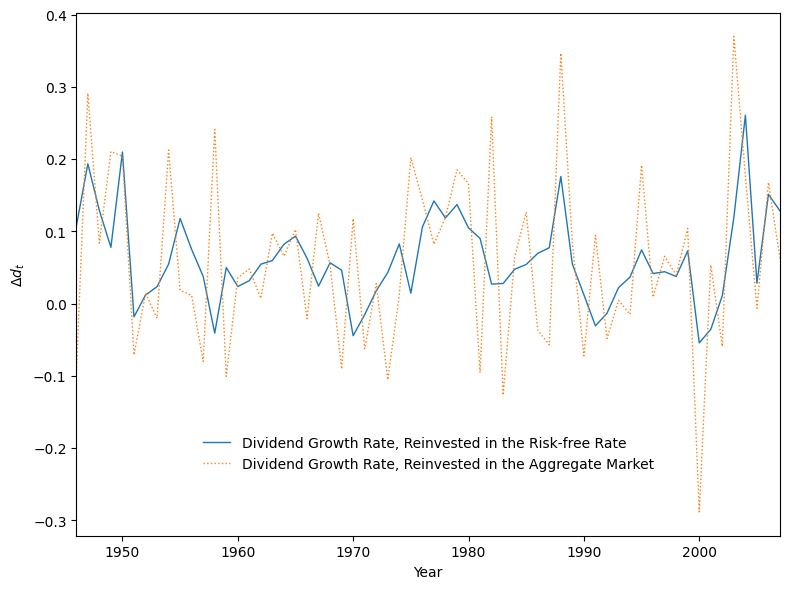

In [11]:
# 1946-2007

monthly, annual = monthly_annual(
    ret_df,
    tbill_df,
    end_year=2007
)

growth, table1 = replicate_table1(annual, start_year=1946, end_year=2007)
table3, models3 = replicate_table3(annual, start_year=1946, end_year=2007)
reg4, table4, models4 = replicate_table4(annual, start_year=1946, end_year=2007)

print("Table 1")
print(table1.round(4))
print()

print("Table 3")
print(table3.round(4))
print()

print("Table 4")
print(table4.round(4))

replicate_figure1(annual, start_year=1946, end_year=2007)

In [12]:
from pathlib import Path
from settings import config
DATA_DIR = Path(config("DATA_DIR"))


(table1.round(4)).to_csv(DATA_DIR / "dividend_growth_stats.csv", index=True)
(table3.round(4)).to_csv(DATA_DIR / "OLS_predictive_regressions.csv", index=True)
(table4.round(4)).to_csv(DATA_DIR / "specs_for_market_reinvested_dividend_growth.csv", index=True)

In [26]:
tbill_df_latest = pd.read_parquet("../_data/CRSP_30_day_T_bill_44_to_latest.parquet")
ret_df_latest = pd.read_parquet("../_data/CRSP_monthly_stock_44_to_latest.parquet")

In [27]:
tbill_df_latest

,date,t30ret
0,1944-01-31,0.000293
1,1944-02-29,0.000289
2,1944-03-31,0.000238
3,1944-04-29,0.000277
4,1944-05-31,0.000261
...,...,...
967,2024-08-30,0.004419
968,2024-09-30,0.004619
969,2024-10-31,0.003907
970,2024-11-29,0.003955


In [28]:
ret_df_latest

,date,vwretd,vwretx
0,1944-01-31,0.018030,0.016629
1,1944-02-29,0.003459,-0.001591
2,1944-03-31,0.024768,0.019977
3,1944-04-29,-0.016484,-0.017836
4,1944-05-31,0.050909,0.044927
...,...,...,...
980,2025-09-30,0.035627,0.034163
981,2025-10-31,0.019285,0.018508
982,2025-11-28,0.001994,0.000849
983,2025-12-31,0.001296,-0.000601


In [29]:
tbill_df_24=tbill_df_latest
ret_df_24=ret_df_latest.head(len(tbill_df_latest))

Table 1
                    delta_d_M  delta_d
Mean                   0.0587   0.0599
Median                 0.0534   0.0547
Standard deviation     0.1284   0.0678
Maximum                0.3697   0.2609
Minimum               -0.2884  -0.1885

Table 3
                              r_M       r  delta_d_M  delta_d
Constant                   0.4525  0.4580     0.1772   0.0765
SE(Constant)               0.1482  0.1453     0.1194   0.0632
Lagged log PD coefficient -0.0998 -0.1007    -0.0339  -0.0047
SE(Lagged log PD)          0.0420  0.0408     0.0338   0.0178
R2                         0.0684  0.0733     0.0128   0.0009
Adj. R2                    0.0563  0.0613     0.0000  -0.0121

Table 4
                 AR1  r_lag_only  ARMAX11_r_lag
Constant      0.0749      0.1009         0.0584
SE(Constant)  0.0154      0.0147         0.0116
AR(1)        -0.2739         NaN         0.3973
SE(AR(1))     0.1096         NaN         0.1920
MA(1)            NaN         NaN        -0.4241
SE(MA(1))        N

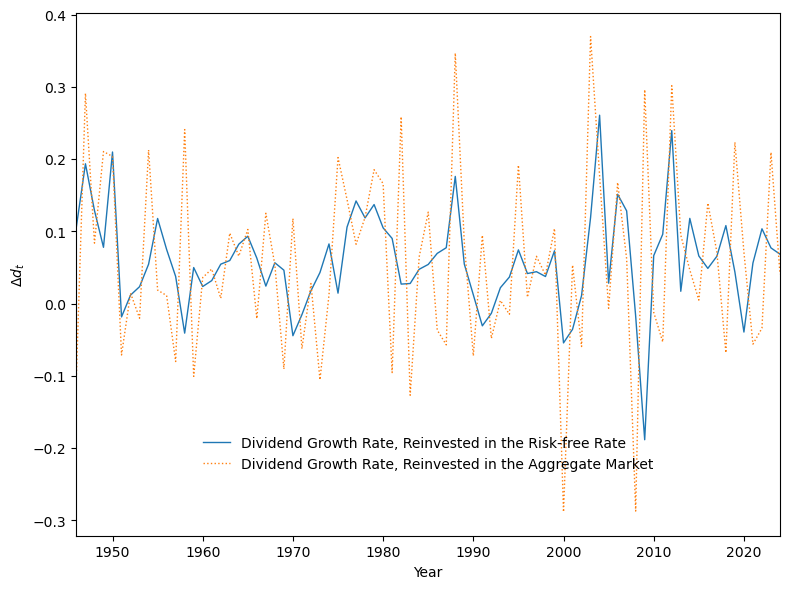

In [30]:
# 1946-2024

monthly, annual = monthly_annual(
    ret_df_24,
    tbill_df_24,
    end_year=2024
)

growth, table1 = replicate_table1(annual, start_year=1946, end_year=2024)
table3, models3 = replicate_table3(annual, start_year=1946, end_year=2024)
reg4, table4, models4 = replicate_table4(annual, start_year=1946, end_year=2024)

print("Table 1")
print(table1.round(4))
print()

print("Table 3")
print(table3.round(4))
print()

print("Table 4")
print(table4.round(4))

replicate_figure1(annual, start_year=1946, end_year=2024)